# Learning curves

For **blended** and **VAE** separately: **N = 0** from `orig/`, **N = 400–2000** from the matching synthesis folder.

- **Training loss** — `{cnn|fcnn}_train_loss_{N}.csv`
- **Training accuracy (per epoch)** — `{cnn|fcnn}_epoch_train_acc_{N}.csv` (Keras `acc`) and labels the figure accordingly.

**Test metrics** — mean ± std over run/seed rows in `test_{cnn|fcnn}_results_{N}.csv` (`accuracy` and `bal_accuracy` columns).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "results").is_dir():
    ROOT = ROOT.parent

SYNTH_LEVELS = (0, 400, 800, 1200, 1600, 2000)
MODELS = ("cnn", "fcnn")
SYNTH_MODES = ("blended", "vae")
DATASETS = ("chlorinated", "sars")

N_COLORS = plt.cm.viridis(np.linspace(0.15, 0.95, len(SYNTH_LEVELS)))

In [2]:
def load_loss_matrix(csv_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Row 0 = epoch index; remaining rows = one curve per run."""
    df = pd.read_csv(csv_path, header=None)
    epochs = df.iloc[0].to_numpy(dtype=float)
    vals = df.iloc[1:].to_numpy(dtype=float)
    return epochs, vals

def csv_path_train_loss(dataset: str, synth_mode: str, model: str, n_synth: int) -> Path | None:
    sub = "orig" if n_synth == 0 else synth_mode
    p = ROOT / "results" / dataset / sub / f"{model}_train_loss_{n_synth}.csv"
    return p if p.is_file() else None


def csv_path_train_acc(dataset: str, synth_mode: str, model: str, n_synth: int) -> Path | None:
    sub = "orig" if n_synth == 0 else synth_mode
    p = ROOT / "results" / dataset / sub / f"{model}_epoch_train_acc_{n_synth}.csv"
    return p if p.is_file() else None

## Training loss — `orig` only (N = 0)

Reads `results/<dataset>/orig/{cnn|fcnn}_train_loss_0.csv`.

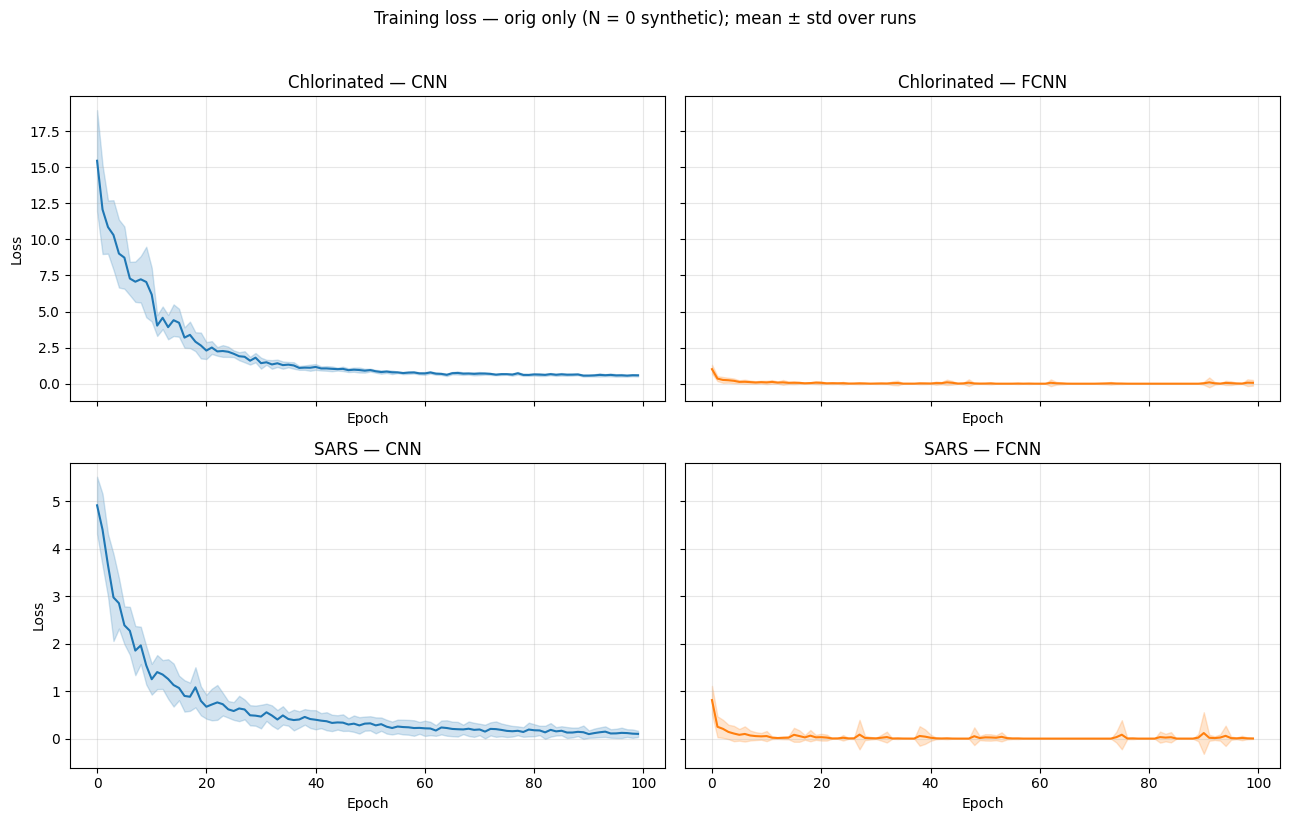

In [3]:
def plot_orig_only_training_loss() -> None:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey="row")
    row_titles = ("Chlorinated", "SARS")
    colors = {"cnn": "C0", "fcnn": "C1"}
    for r, ds in enumerate(DATASETS):
        for c, model in enumerate(MODELS):
            ax = axes[r, c]
            p = ROOT / "results" / ds / "orig" / f"{model}_train_loss_0.csv"
            if not p.is_file():
                ax.text(
                    0.5,
                    0.5,
                    f"Missing file:\n{p.name}",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=10,
                )
            else:
                epochs, vals = load_loss_matrix(p)
                mean = vals.mean(axis=0)
                std = vals.std(axis=0, ddof=0)
                col = colors[model]
                ax.plot(epochs, mean, color=col)
                ax.fill_between(epochs, mean - std, mean + std, color=col, alpha=0.2)
            ax.set_title(f"{row_titles[r]} — {model.upper()}")
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)
        axes[r, 0].set_ylabel("Loss")
    fig.suptitle(
        "Training loss — orig only (N = 0 synthetic); mean ± std over runs",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


plot_orig_only_training_loss()

In [ ]:
## Training loss — `orig` only (N = 0)

One row, two columns (**CNN** left, **FCNN** right). Each panel overlays **chlorinated** and **SARS** (two curves). Reads `results/<dataset>/orig/{cnn|fcnn}_train_loss_0.csv` only.

In [ ]:
def plot_orig_only_training_loss() -> None:
    """One row (1×2): CNN | FCNN. Each panel: chlorinated + SARS overlaid (orig, N = 0)."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
    ds_colors = {"chlorinated": "C0", "sars": "C1"}
    ds_labels = {"chlorinated": "Chlorinated", "sars": "SARS"}

    for c, model in enumerate(MODELS):
        ax = axes[c]
        plotted = False
        for ds in DATASETS:
            path = ROOT / "results" / ds / "orig" / f"{model}_train_loss_0.csv"
            if not path.is_file():
                continue
            epochs, vals = load_loss_matrix(path)
            mean = vals.mean(axis=0)
            std = vals.std(axis=0, ddof=0)
            col = ds_colors[ds]
            lbl = ds_labels[ds]
            ax.plot(epochs, mean, color=col, label=lbl)
            ax.fill_between(epochs, mean - std, mean + std, color=col, alpha=0.18)
            plotted = True
        if not plotted:
            ax.text(
                0.5,
                0.5,
                "No train_loss CSV found\nfor this model",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=10,
            )
        ax.set_title(model.upper())
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)
        if plotted:
            ax.legend(loc="best", title="Dataset")

    fig.suptitle(
        "Training loss — orig only (N = 0 synthetic); mean ± std over runs",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


plot_orig_only_training_loss()

## Test set metrics (vs synthetic sample count)

Same layout as training: **blended** / **VAE**, **CNN | FCNN**, **orig** for **N = 0**.

In [ ]:
def csv_path_test(dataset: str, synth_mode: str, model: str, n_synth: int) -> Path | None:
    sub = "orig" if n_synth == 0 else synth_mode
    p = ROOT / "results" / dataset / sub / f"test_{model}_results_{n_synth}.csv"
    return p if p.is_file() else None


def plot_test_combined_figure(
    dataset: str, synth_mode: str, metric_col: str, metric_label: str
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)
    fig.suptitle(
        f"{dataset} — {synth_mode} synthesis — {metric_label}\n"
        f"(N = 0 from orig; N = 400–2000 from {synth_mode}; mean ± std over run/seed rows)",
        fontsize=11,
    )

    for ax, model in zip(axes, MODELS):
        xs: list[int] = []
        means: list[float] = []
        stds: list[float] = []
        for n in SYNTH_LEVELS:
            path = csv_path_test(dataset, synth_mode, model, n)
            if path is None:
                continue
            df = pd.read_csv(path)
            xs.append(n)
            means.append(float(df[metric_col].mean()))
            stds.append(float(df[metric_col].std(ddof=0)))
        if not xs:
            ax.text(0.5, 0.5, "no CSV", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(model.upper())
            continue
        xs_arr = np.array(xs)
        means_arr = np.array(means)
        stds_arr = np.array(stds)
        for i, n in enumerate(xs):
            idx = SYNTH_LEVELS.index(n)
            color = N_COLORS[idx]
            ax.errorbar(
                [n],
                [means[i]],
                yerr=[stds[i]],
                fmt="o",
                color=color,
                capsize=4,
                markersize=7,
                label=f"N = {n}",
            )
        order = np.argsort(xs_arr)
        ax.plot(xs_arr[order], means_arr[order], color="0.55", alpha=0.75, linewidth=1.2, zorder=0)
        ax.set_title(model.upper())
        ax.set_xlabel("Synthetic samples added")
        ax.grid(True, alpha=0.3)
        ax.set_xticks(list(SYNTH_LEVELS))
        ax.legend(loc="best", fontsize=8, title="Synth. samples")

    axes[0].set_ylabel(metric_label)
    plt.tight_layout()
    plt.show()


TEST_METRIC_SPECS: tuple[tuple[str, str], ...] = (
    ("accuracy", "Test accuracy"),
    ("bal_accuracy", "Test balanced accuracy"),
)

for dataset in DATASETS:
    if not (ROOT / "results" / dataset).is_dir():
        print(f"Skip missing: {dataset}")
        continue
    for synth_mode in SYNTH_MODES:
        for metric_col, metric_label in TEST_METRIC_SPECS:
            plot_test_combined_figure(dataset, synth_mode, metric_col, metric_label)

## CSV inventory

In [ ]:
rows = []
for ds in DATASETS:
    droot = ROOT / "results" / ds
    if not droot.is_dir():
        continue
    for sub in sorted(p for p in droot.iterdir() if p.is_dir()):
        for p in sorted(sub.glob("*.csv")):
            if any(
                x in p.name
                for x in (
                    "train_loss",
                    "epoch_train_acc",
                    "epoch_train_bal_acc",
                )
            ):
                rows.append(
                    {"dataset": ds, "subdir": sub.name, "file": p.name, "path": str(p.relative_to(ROOT))}
                )
            if p.name.startswith("test_") and "summary" not in p.name and p.name.endswith(".csv"):
                rows.append(
                    {"dataset": ds, "subdir": sub.name, "file": p.name, "path": str(p.relative_to(ROOT))}
                )
pd.DataFrame(rows).drop_duplicates("path")